In [7]:
# 1. Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

import spacy
import joblib

# Load English model for NER
nlp = spacy.load("en_core_web_sm")

In [8]:
# 2. Load Dataset
data = pd.read_csv("/content/Cleaned_FakeNews.csv")
print("Dataset Shape:", data.shape)
print(data.head())

Dataset Shape: (20557, 3)
                                                text    subject target
0  new us ambassador nikki haley strutted un frid...   politics   fake
1  buenos aires reuters argentina congress passed...  worldnews   TRUE
2  ankara reuters iraqi prime minister haider ala...  worldnews   TRUE
3  first half debate donald trump seemed bogged d...       News   fake
4  wanted assimilate gave good job trusted offere...   politics   fake


In [9]:

# 3. Encode Target Labels: TRUE -> 1, fake -> 0
data['target'] = data['target'].map({'TRUE': 1, 'fake': 0})

print(data['target'].value_counts())
print(data.head())


target
0.0    10820
1.0     9731
Name: count, dtype: int64
                                                text    subject  target
0  new us ambassador nikki haley strutted un frid...   politics     0.0
1  buenos aires reuters argentina congress passed...  worldnews     1.0
2  ankara reuters iraqi prime minister haider ala...  worldnews     1.0
3  first half debate donald trump seemed bogged d...       News     0.0
4  wanted assimilate gave good job trusted offere...   politics     0.0


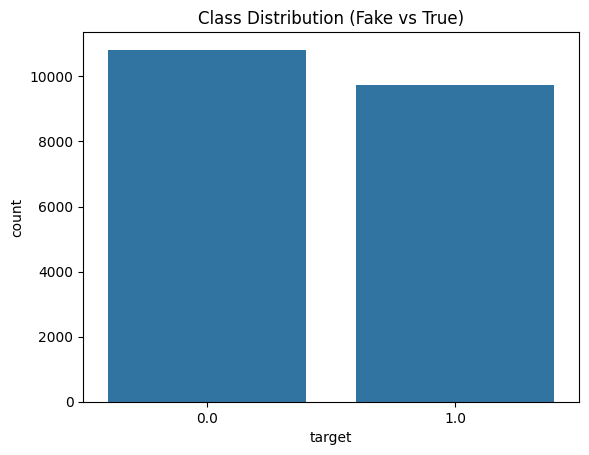

In [10]:
# 4. Check Class Balance
sns.countplot(x=data['target'])
plt.title("Class Distribution (Fake vs True)")
plt.show()

In [22]:

# 5. Named Entity Recognition (NER) Example
def extract_entities(text):
    doc = nlp(text)
    return [(ent.text, ent.label_) for ent in doc.ents]

# Apply NER
print("\nSample Named Entities:")
for i in range(5):
    print(extract_entities(data['text'].iloc[i]))


Sample Named Entities:
[('us', 'GPE'), ('nikki haley', 'ORG'), ('un', 'ORG'), ('friday', 'DATE'), ('american', 'NORP'), ('south carolina', 'GPE'), ('manhattan', 'GPE'), ('un', 'ORG'), ('antonio guterres', 'PERSON'), ('un', 'ORG'), ('saidshe', 'PERSON'), ('un', 'ORG'), ('38th', 'CARDINAL'), ('un', 'ORG'), ('jan 1', 'DATE'), ('white house', 'ORG'), ('un', 'ORG'), ('washington', 'GPE')]
[('reuters argentina congress', 'ORG'), ('tuesday days', 'DATE'), ('mauricio macri', 'PERSON'), ('next year', 'DATE'), ('next years', 'DATE'), ('december 2015 decade', 'DATE'), ('last thursday', 'DATE'), ('monday', 'DATE'), ('thousands', 'CARDINAL'), ('dozens', 'CARDINAL'), ('necessary macri', 'PERSON'), ('127117', 'DATE'), ('two', 'CARDINAL'), ('senate', 'ORG'), ('last month', 'DATE'), ('around 05 percent', 'PERCENT'), ('next year', 'DATE'), ('ariel barraud', 'PERSON'), ('argentina fiscal analysis institute', 'ORG'), ('cordoba argentina', 'PERSON'), ('reuters', 'ORG'), ('argentina', 'GPE'), ('32 percent'

In [23]:
# 6. Relationship Extraction (demo: subject + verb + object)
def extract_relations(text):
    doc = nlp(text)
    relations = []
    for token in doc:
        if token.dep_ in ("ROOT", "relcl") and token.pos_ == "VERB":
            subject = [w.text for w in token.lefts if w.dep_ in ("nsubj", "nsubjpass")]
            obj = [w.text for w in token.rights if w.dep_ in ("dobj", "pobj")]
            if subject and obj:
                relations.append((subject[0], token.text, obj[0]))
    return relations

print("\nSample Relations:")
for i in range(5):
    print(extract_relations(data['text'].iloc[i]))


Sample Relations:
[]
[('congress', 'passed', 'system')]
[]
[('drugs', 'done', 'trump')]
[]


In [24]:
# 7. Feature Extraction (TF-IDF)
vectorizer = TfidfVectorizer(max_features=5000, stop_words='english')
X = vectorizer.fit_transform(data['text'])
y = data['target']

print("Feature matrix shape:", X.shape)

Feature matrix shape: (20551, 5000)


In [25]:
# 8. Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [26]:
# 9. Model Training
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [27]:
# 10. Model Evaluation
y_pred = model.predict(X_test)

print("✅ Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))


✅ Accuracy: 0.9849185113111165

Classification Report:
               precision    recall  f1-score   support

         0.0       0.99      0.98      0.99      2149
         1.0       0.98      0.99      0.98      1962

    accuracy                           0.98      4111
   macro avg       0.98      0.98      0.98      4111
weighted avg       0.98      0.98      0.98      4111


Confusion Matrix:
 [[2115   34]
 [  28 1934]]


In [28]:
# 11. Test with New Example
sample_news = [
    "Donald Trump says the US economy is booming under his leadership",
    "Aliens have landed in New York City according to anonymous sources"
]

sample_features = vectorizer.transform(sample_news)
predictions = model.predict(sample_features)

for news, label in zip(sample_news, predictions):
    print(f"\nNews: {news}\nPrediction: {'True' if label==1 else 'Fake'}")


News: Donald Trump says the US economy is booming under his leadership
Prediction: Fake

News: Aliens have landed in New York City according to anonymous sources
Prediction: Fake


In [29]:
# 11. Save Model & Vectorizer for Streamlit Demo
joblib.dump(model, "fake_news_model.pkl")
joblib.dump(vectorizer, "tfidf_vectorizer.pkl")

print("✅ Model & Vectorizer Saved!")


✅ Model & Vectorizer Saved!
